# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Ahmad Izzuddin Ulinnuha]
- **Email:** [ahmzudin@gmail.com]
- **ID Dicoding:** [zudin_ulinnuha]

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Instalasi library tambahan
!pip install split-folders tensorflowjs

# Import seluruh library
import os
import zipfile
import splitfolders
import numpy as np
import tensorflow as tf
import tensorflowjs as tfjs
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import Callback

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Data Preparation

### Data Loading

In [11]:
# Upload kaggle.json
print("Silakan upload file kaggle.json Anda:")
uploaded = files.upload()

# Konfigurasi Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dan ekstrak Rice Image Dataset
!kaggle datasets download -d muratkokludataset/rice-image-dataset

local_zip = 'rice-image-dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/dataset')
zip_ref.close()

base_dir = '/tmp/dataset/Rice_Image_Dataset'

# Hapus file txt bawaan dataset agar tidak terbaca sebagai kelas
txt_file = os.path.join(base_dir, 'Rice_Citation_Request.txt')
if os.path.exists(txt_file):
    os.remove(txt_file)

print("Kelas yang tersedia:", os.listdir(base_dir))

Silakan upload file kaggle.json Anda:


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
rice-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Kelas yang tersedia: ['Jasmine', 'Karacadag', 'Arborio', 'Basmati', 'Ipsala']


### Data Preprocessing

#### Split Dataset

In [12]:
output_dir = '/tmp/rice_splitted'

# Membagi folder dengan rasio 80% Train, 10% Val, 10% Test
splitfolders.ratio(
    base_dir,
    output=output_dir,
    seed=42,
    ratio=(.8, .1, .1),
    group_prefix=None
)

train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

print("Dataset berhasil di-split!")

Copying files: 75000 files [00:17, 4323.69 files/s]

Dataset berhasil di-split!


In [13]:
# Augmentasi untuk Data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Rescale saja untuk Val dan Test
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 60000 images belonging to 5 classes.
Found 7500 images belonging to 5 classes.
Found 7500 images belonging to 5 classes.


## Modelling

In [14]:
# Arsitektur CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Mencegah overfitting
    Dense(5, activation='softmax') # 5 Kelas beras
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Custom Callback untuk target Akurasi > 95%
class TargetCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96):
            print("\nTarget akurasi > 96% tercapai, menghentikan training!")
            self.model.stop_training = True

# Proses Pelatihan
history = model.fit(
    train_generator,
    epochs=15, # Set ke 15 atau 20
    validation_data=val_generator,
    callbacks=[TargetCallback()],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 371s 196ms/step - accuracy: 0.9168 - loss: 0.2114 - val_accuracy: 0.9715 - val_loss: 0.0858
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 378s 202ms/step - accuracy: 0.9794 - loss: 0.0614 - val_accuracy: 0.8791 - val_loss: 0.5699
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9804 - loss: 0.0585
Target akurasi > 96% tercapai, menghentikan training!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 378s 201ms/step - accuracy: 0.9819 - loss: 0.0555 - val_accuracy: 0.9641 - val_loss: 0.1509


## Evaluasi dan Visualisasi

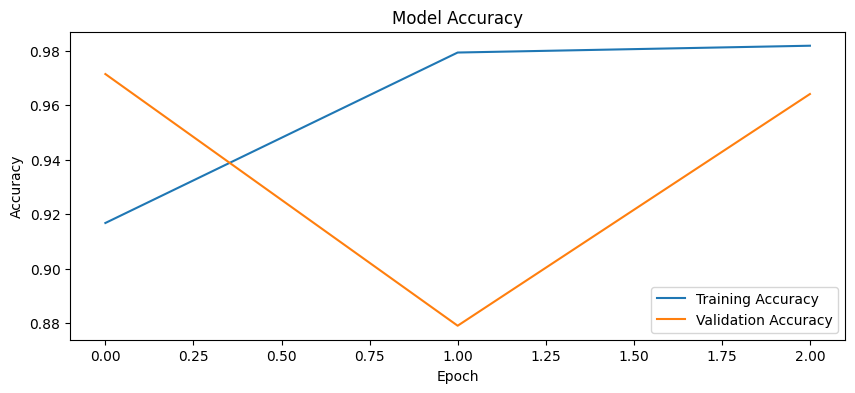

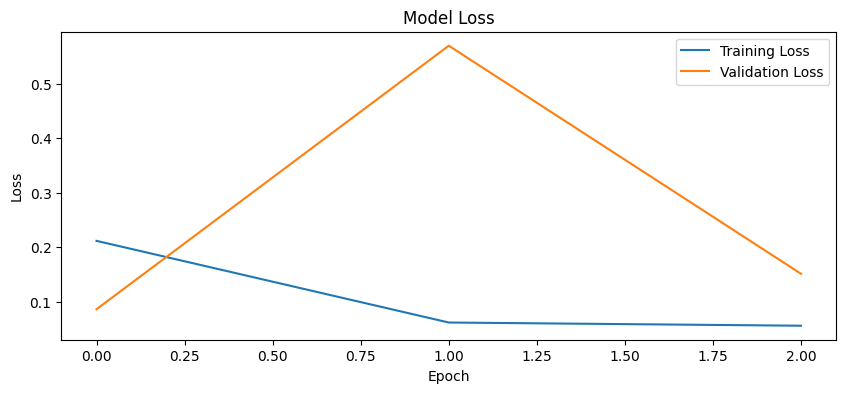

235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9588 - loss: 0.1538
Akurasi pada Test Set: 95.88%


In [15]:
# Plot Akurasi
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

# Plot Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Evaluasi pada Test Set (Kriteria 3 & 5)
loss, accuracy = model.evaluate(test_generator)
print(f"Akurasi pada Test Set: {accuracy * 100:.2f}%")

## Konversi Model

In [16]:
# 1. Export ke format SavedModel
model.export('saved_model_dir')

# 2. Export ke format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_dir = 'tflite'
os.makedirs(tflite_dir, exist_ok=True)
with open(os.path.join(tflite_dir, 'model.tflite'), 'wb') as f:
    f.write(tflite_model)

# Tulis label kelas untuk TFLite
labels = '\n'.join(sorted(train_generator.class_indices.keys()))
with open(os.path.join(tflite_dir, 'label.txt'), 'w') as f:
    f.write(labels)

# 3. Export ke format TFJS
tfjs_dir = 'tfjs_model'
tfjs.converters.save_keras_model(model, tfjs_dir)

print("Semua konversi model berhasil disimpan!")

Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_17')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138519323689040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323690192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323689616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323700560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323691536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323689424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323691920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323702864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138519323690768: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact

failed to lookup keras version from the file,
    this is likely a weight only file
Semua konversi model berhasil disimpan!


## Inference (Optional)

Unggah gambar beras untuk diuji:


Saving Cuplikan layar 2026-05-11 093935.png to Cuplikan layar 2026-05-11 093935 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step

File: Cuplikan layar 2026-05-11 093935 (1).png
Prediksi Kelas: Ipsala


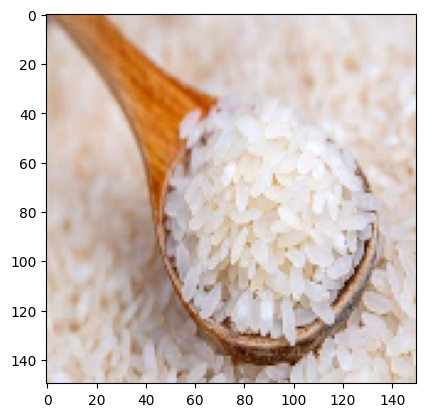

In [17]:
print("Unggah gambar beras untuk diuji:")
uploaded_test = files.upload()

for fn in uploaded_test.keys():
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocessing (Rescale) yang sama dengan generator
    x = x / 255.0

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)

    print('\nFile:', fn)
    class_list = sorted(train_generator.class_indices.keys())
    predicted_class = class_list[np.argmax(classes)]
    print('Prediksi Kelas:', predicted_class)